# Part 2: Full Project — Titanic Survival Prediction with KNN

**English:** We now build a complete KNN pipeline on the Titanic dataset from scratch: load data, clean it, engineer features, scale, find the best K, train, and evaluate.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style('whitegrid')

## Step 1: Load the Dataset

**English:** Load the Titanic dataset from seaborn and preview it.

**Roman Urdu:** Seaborn se Titanic dataset load kar rahe hain aur preview dekh rahe hain.

In [3]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Step 2: Check Missing Values

**English:** See which columns have missing data and how much.


In [4]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Step 3: Fill Missing `age` (Group-wise by Class & Gender)

**English:** Instead of one overall average, we fill missing ages using the average age of passengers with the same `pclass` and `sex` — this is more accurate than a single global mean.


In [5]:
def input_age(pclass, sex):
    return titanic[(titanic['pclass']==pclass) & (titanic['sex']==sex)]['age'].mean()

titanic['age'] = titanic.apply(
    lambda x: input_age(x['pclass'], x['sex']) if np.isnan(x['age']) else x['age'], axis=1
)
titanic['age'].isnull().sum()

np.int64(0)

## Step 4: Drop `deck` (Too Many Missing Values)

**English:** `deck` is missing for ~77% of rows, so it's not useful — we drop it.

In [6]:
titanic.drop('deck', axis=1, inplace=True)

## Step 5: Fill Missing `embarked`

**English:** Only 2 rows are missing `embarked`; we fill them with the mode (most common port).


In [7]:
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic['embark_town'] = titanic['embark_town'].fillna(titanic['embark_town'].mode()[0])
titanic.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

## Step 6: Drop Redundant / Data-Leakage Columns

**English:** `alive` directly leaks the target (it's just `survived` as yes/no). `who`, `adult_male`, `class`, `embark_town`, `alone` are all derived from other columns already in our data — keeping them adds redundancy without new information.

In [8]:
titanic.drop(['alive', 'who', 'adult_male', 'class', 'embark_town', 'alone'], axis=1, inplace=True)
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Step 7: Encode Categorical Variables

**English:** KNN needs numeric data (it computes distances). We convert `sex` and `embarked` into numeric dummy columns using one-hot encoding.


In [9]:
sex = pd.get_dummies(titanic['sex'], drop_first=True)
embarked = pd.get_dummies(titanic['embarked'], drop_first=True, prefix='embarked')

titanic = pd.concat([titanic, sex, embarked], axis=1)
titanic.drop(['sex', 'embarked'], axis=1, inplace=True)
titanic.head()

,survived,pclass,age,sibsp,parch,fare,male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


## Step 8: Define X and y

**English:** `survived` is the target; everything else is a feature.

In [10]:
X = titanic.drop('survived', axis=1)
y = titanic['survived']

## Step 9: Train-Test Split

**English:** 80% training, 20% testing.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((712, 8), (179, 8))

## Step 10: Scale the Features

**English:** Just like in Part 1, we must scale features before using KNN — columns like `fare` (0–500+) would otherwise dominate distance calculations over columns like `sibsp` (0–8).

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 11: Find the Best K (Elbow Method)

**English:** Same approach as Part 1 — try many K values and pick the one with the lowest test error.

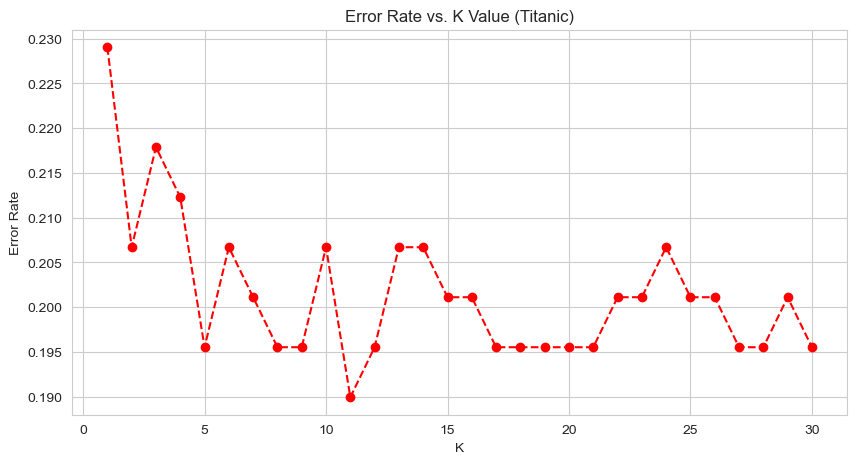

Best K: 11 | Lowest Error Rate: 0.18994413407821228


In [13]:
error_rates = []

for k in range(1, 31):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    pred_k = knn_k.predict(X_test_scaled)
    error_rates.append(np.mean(pred_k != y_test))

plt.figure(figsize=(10,5))
plt.plot(range(1,31), error_rates, marker='o', linestyle='--', color='red')
plt.title('Error Rate vs. K Value (Titanic)')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

best_k = error_rates.index(min(error_rates)) + 1
print("Best K:", best_k, "| Lowest Error Rate:", min(error_rates))

## Step 12: Train the Final KNN Model

**English:** Train the final model using the best K found above.

In [14]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Step 13: Predict and Evaluate

**English:** Predict on the test set and check accuracy, confusion matrix, and classification report.

In [15]:
predictions = knn_final.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, predictions))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))

Accuracy: 0.8100558659217877

Confusion Matrix:
 [[93 12]
 [22 52]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       105
           1       0.81      0.70      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



## Step 14: Visualize the Confusion Matrix

**English:** A heatmap makes it easy to see correct vs incorrect predictions for each class at a glance.

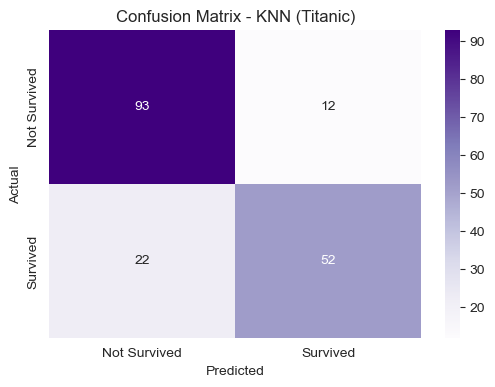

In [16]:
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Survived','Survived'], yticklabels=['Not Survived','Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN (Titanic)')
plt.show()

## Conclusion / Nateeja

**English:** We practiced KNN step-by-step on the Iris dataset (understanding distance, scaling, and choosing K), then applied the same workflow to a full Titanic project: cleaning data, removing leakage columns, encoding categories, scaling features, finding the best K, and evaluating the final model.

**Roman Urdu:** Humne pehle Iris dataset par KNN step-by-step practice ki (distance, scaling, aur K chunne ko samjha), phir wahi workflow ek mukammal Titanic project par apply ki: data clean karna, leakage columns hatana, categories encode karna, features scale karna, best K dhoondna, aur final model evaluate karna.